# Polynomial Regression

In [2]:
# create dataset

import numpy as np
import pandas as pd

np.random.seed(42)

X = np.linspace(-3, 3, 30)

y = 2 * X**2 + 3 * X + 5 + np.random.normal(0, 2, 30)

data = pd.DataFrame({
    "x": X,
    "y": y
})

data.head()

,x,y
0,-3.000000,14.993428
1,-2.793103,11.947015
2,-2.586207,11.913689
3,-2.379310,12.230364
4,-2.172414,7.453215


In [3]:
# Try Linear Regression First
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(data[["x"]], data["y"])

y_pred_linear = linear_model.predict(data[["x"]])

d:\Learning\AI_Eng\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


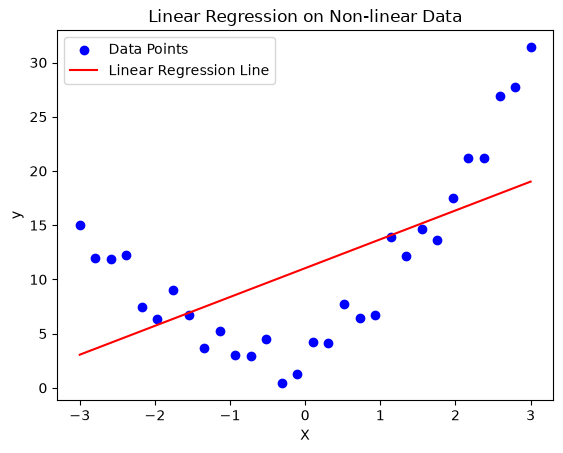

In [4]:
# Visualize the results
import matplotlib.pyplot as plt
 
plt.scatter(data["x"], data["y"], color='blue', label='Data Points')
plt.plot(data["x"], y_pred_linear, color='red', label='Linear Regression Line')

plt.title('Linear Regression on Non-linear Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

plt.show()

**Conclusion**
Since the data patterns are in curve, using linear regression doesn't make sense here as we won't be getting any proper result for this as seen in the diagram

In [ ]:
# Add polynomial features to the dataset
from sklearn.preprocessing import PolynomialFeatures

polynomial_features = PolynomialFeatures(degree=2)

x_poly = polynomial_features.fit_transform(data[["x"]])

x_poly[:5]  # Display the first 5 rows of the transformed features

array([[ 1.        , -3.        ,  9.        ],
       [ 1.        , -2.79310345,  7.80142687],
       [ 1.        , -2.5862069 ,  6.68846611],
       [ 1.        , -2.37931034,  5.66111772],
       [ 1.        , -2.17241379,  4.71938169]])

In [6]:
# Now we can fit a linear regression model to the polynomial features
polynomial_model = LinearRegression()

polynomial_model.fit(x_poly, data["y"])

# predict using the polynomial model
y_pred_poly = polynomial_model.predict(x_poly)

In [7]:
# Compare the results of linear and polynomial regression
from sklearn.metrics import mean_squared_error

linear_mse = mean_squared_error(data["y"], y_pred_linear)
polynomial_mse = mean_squared_error(data["y"], y_pred_poly)

print(f"Mean Squared Error (Linear Regression): {linear_mse:.2f}")
print(f"Mean Squared Error (Polynomial Regression): {polynomial_mse:.2f}")

Mean Squared Error (Linear Regression): 41.13
Mean Squared Error (Polynomial Regression): 2.53


In [8]:
# In real world we use pipeline to avoid data leakage and make the code cleaner. Let's see how we can do that.
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

model_pipeline = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

model_pipeline.fit(data[["x"]], data["y"])

preicted_y_pipeline = model_pipeline.predict(data[["x"]])

**What does degree mean?**
- It is main hyperparameter.
- It can be x, x² ...


**Degree too low tends to Underfitting and too high tends to Overfitting**

In [9]:
# Let's compare the polynomial degree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np

x_train, x_test, y_train, y_test = train_test_split(data[["x"]], data["y"], test_size=0.2, random_state=42)

for degree in [1,2,3,5,10]:
    model_pipeline = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())
    model_pipeline.fit(x_train, y_train)
    
    train_pred = model_pipeline.predict(x_train)
    test_pred = model_pipeline.predict(x_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    print(f"Degree: {degree}, Train RMSE: {train_rmse:.2f}, Test RMSE: {test_rmse:.2f}")

Degree: 1, Train RMSE: 6.59, Test RMSE: 5.85
Degree: 2, Train RMSE: 1.64, Test RMSE: 1.36
Degree: 3, Train RMSE: 1.64, Test RMSE: 1.36
Degree: 5, Train RMSE: 1.49, Test RMSE: 1.65
Degree: 10, Train RMSE: 1.28, Test RMSE: 2.31


**When to use polynomial regression**
1. When relationship is visibly non-linear.
2. We have relatively few features.
3. Want a simple nonlinear baseline.


**When to Avoid?**
1. High Dimensional Data (Like 1000 features)
2. Very Complex Non Linear Relationship
3. High Degree Polynomial


## Exercise

In [10]:
np.random.seed(42)

X = np.linspace(-3, 3, 30)

y = 2 * X**2 + 3 * X + 5 + np.random.normal(0, 2, 30)

data = pd.DataFrame({
    "x": X,
    "y": y
})

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degrees = [1, 2, 5, 10]

x_train, x_test, y_train, y_test = train_test_split(data[["x"]], data["y"], test_size=0.2, random_state=42)

for degree in degrees:
    model_pipeline = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())
    model_pipeline.fit(x_train, y_train)
    
    train_pred = model_pipeline.predict(x_train)
    test_pred = model_pipeline.predict(x_test)

    train_rmse = root_mean_squared_error(y_train, train_pred)
    test_rmse = root_mean_squared_error(y_test, test_pred)

    print(f"Degree: {degree}, Train RMSE: {train_rmse:.2f}, Test RMSE: {test_rmse:.2f}")

Degree: 1, Train RMSE: 6.59, Test RMSE: 5.85
Degree: 2, Train RMSE: 1.64, Test RMSE: 1.36
Degree: 5, Train RMSE: 1.49, Test RMSE: 1.65
Degree: 10, Train RMSE: 1.28, Test RMSE: 2.31
